# Freature Analysis
Using the results from the previous analysis we will explore all features that should be used for the ranking system, such as revenue, demand, take rate, whether a merchant sells essential products, demographic profile of each customer and fraud.

In [1]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyspark.sql.functions as F

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/06 15:50:31 WARN Utils: Your hostname, CompuPau, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/10/06 15:50:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/10/06 15:50:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


**Explore rankings created for merchants, determine importance of these features.**

In [3]:
merchant_summary = (
    spark.read.parquet("../data/curated/final_external_enriched")
    .groupBy("merchant_abn")
    .agg(
        F.first("take_rate", ignorenulls=True).alias("take_rate"),
        F.sum("dollar_value").alias("total_dollar_value"),
        F.count("order_id").alias("num_transactions"),
        F.avg("fraud_probability").alias("mean_fraud_probability"),
    )
)

print("Merchants:", merchant_summary.count())
print("Unique merchants:", merchant_summary.select("merchant_abn").distinct().count())
merchant_summary.printSchema()

Merchants: 4026
Unique merchants: 4026
root
 |-- merchant_abn: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_dollar_value: double (nullable = true)
 |-- num_transactions: long (nullable = false)
 |-- mean_fraud_probability: double (nullable = true)



In [4]:
# rankings of merchants by dollar value and number of transactions
rankings_pd = merchant_summary.toPandas()

rankings_pd["rank_take_rate"] = rankings_pd["take_rate"].rank(ascending=False, method="first").astype(int)
rankings_pd["rank_dollar_value"] = rankings_pd["total_dollar_value"].rank(ascending=False, method="first").astype(int)
rankings_pd["rank_num_transactions"] = rankings_pd["num_transactions"].rank(ascending=False, method="first").astype(int)

# avg_rank =average of both (less is better)(menor = mejor)
rankings_pd["avg_rank_dollar"] = (rankings_pd["rank_take_rate"] + rankings_pd["rank_dollar_value"]) / 2
rankings_pd["avg_rank_num_tx"] = (rankings_pd["rank_take_rate"] + rankings_pd["rank_num_transactions"]) / 2

print("Rows:", len(rankings_pd))
key_cols = ["merchant_abn", "take_rate", "total_dollar_value", "num_transactions"]
print("Nulls:\n", rankings_pd[key_cols].isna().sum())

# Spearman entre los tres rankings
rank_cols = ["rank_take_rate", "rank_dollar_value", "rank_num_transactions"]
print(rankings_pd[rank_cols].corr(method="spearman").round(3))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Rows: 4026
Nulls:
 merchant_abn          0
take_rate             0
total_dollar_value    0
num_transactions      0
dtype: int64
                       rank_take_rate  rank_dollar_value  \
rank_take_rate                  1.000              0.027   
rank_dollar_value               0.027              1.000   
rank_num_transactions           0.060              0.741   

                       rank_num_transactions  
rank_take_rate                         0.060  
rank_dollar_value                      0.741  
rank_num_transactions                  1.000  


**Features**
BNPL considers the amount of money they can recieve, for this reason we will calculate the estimated revenue as `take_rate × dollar value`.

In [5]:
# Percentile rank where ties get the same value (0 to 1, higher = better)
# gives same value to ties, and the average of the ranks for ties
rankings_pd["pct_take_rate"] = rankings_pd["take_rate"].rank(pct=True, method="average")
rankings_pd["pct_dollar_value"] = rankings_pd["total_dollar_value"].rank(pct=True, method="average")
rankings_pd["pct_num_tx"] = rankings_pd["num_transactions"].rank(pct=True, method="average")

In [6]:
# calculate estimated revenue for each merchant based on their take rate and total dollar value
rankings_pd["est_revenue"] = rankings_pd["take_rate"] / 100 * rankings_pd["total_dollar_value"]

cols = ["merchant_abn", "take_rate", "total_dollar_value", "num_transactions", "est_revenue"]
round_map = {"take_rate": 2, "total_dollar_value": 0, "est_revenue": 0}


print("Top 20 by dollar-value ranking")
print(rankings_pd.sort_values("avg_rank_dollar").head(20)[cols].round(round_map).to_string(index=False))

print("\nTop 20 by num-transactions ranking")
print(rankings_pd.sort_values("avg_rank_num_tx").head(20)[cols].round(round_map).to_string(index=False))

# How many of the top 100 are shared between both rankings
top100_r1 = set(rankings_pd.nsmallest(100, "avg_rank_dollar")["merchant_abn"])
top100_r2 = set(rankings_pd.nsmallest(100, "avg_rank_num_tx")["merchant_abn"])
print("\nShared merchants in both top 100:", len(top100_r1 & top100_r2))

Top 20 by dollar-value ranking
merchant_abn  take_rate  total_dollar_value  num_transactions  est_revenue
 45629217853       6.98           8395062.0            228255     585975.0
 12771097467       6.95           4932394.0              1340     342801.0
 35809331583       6.95           2730705.0              1828     189784.0
 79827781481       6.82           9734168.0              4798     663870.0
 71528203369       6.94           1879794.0             32404     130458.0
 58314972637       6.96           1471777.0              4397     102436.0
 98072939449       6.89           3588396.0              5948     247241.0
 16288327194       6.92           1652801.0              3737     114374.0
 45946543693       6.98           1411258.0              3745      98506.0
 31397959824       6.89           1488824.0              6063     102580.0
 81761494572       6.82           3031721.0             26265     206763.0
 13514558491       6.78           5630545.0             17900     381

In [7]:
# Show real take_rate values
print(rankings_pd["take_rate"].describe().round(2))

# Average ticket size per merchant
rankings_pd["avg_ticket"] = rankings_pd["total_dollar_value"] / rankings_pd["num_transactions"]

# How closely does each ranking follow estimated revenue (lower avg_rank = better,
# so we compare against -est_revenue to make both point the same way)
print("Spearman with est_revenue:")
print("  dollar ranking :", round(rankings_pd["avg_rank_dollar"].corr(-rankings_pd["est_revenue"], method="spearman"), 3))
print("  num_tx ranking :", round(rankings_pd["avg_rank_num_tx"].corr(-rankings_pd["est_revenue"], method="spearman"), 3))

# Overlap of each top 100 with the top 100 by estimated revenue
top100_rev = set(rankings_pd.nlargest(100, "est_revenue")["merchant_abn"])
print("Top 100 overlap with est_revenue ranking:")
print("  dollar ranking :", len(top100_r1 & top100_rev))
print("  num_tx ranking :", len(top100_r2 & top100_rev))

count    4026.00
mean        4.40
std         1.78
min         0.10
25%         2.97
50%         4.50
75%         6.03
max         7.00
Name: take_rate, dtype: float64
Spearman with est_revenue:
  dollar ranking : 0.875
  num_tx ranking : 0.705
Top 100 overlap with est_revenue ranking:
  dollar ranking : 25
  num_tx ranking : 19


The ranking of estimated revenue seems highly correlated with the dollar amount and number of transactions. However, among the top 100 merchants, the ones that generate the highest revenue don't necessarily overlap with those with higher dollar value and transaction volume.

In [8]:
top100_rev_df = rankings_pd.nlargest(100, "est_revenue")
missed = top100_rev_df[~top100_rev_df["merchant_abn"].isin(top100_r1)]

cols = ["merchant_abn", "take_rate", "total_dollar_value", "num_transactions",
        "est_revenue", "rank_take_rate", "rank_dollar_value"]
print("In top 100 by revenue but NOT in top 100 of the dollar ranking:", len(missed))
print(missed.sort_values("est_revenue", ascending=False).head(15)[cols].round(
    {"take_rate": 2, "total_dollar_value": 0, "est_revenue": 0}).to_string(index=False))

print("\nTake rate of the missed merchants:")
print(missed["take_rate"].describe().round(2))

In top 100 by revenue but NOT in top 100 of the dollar ranking: 75
merchant_abn  take_rate  total_dollar_value  num_transactions  est_revenue  rank_take_rate  rank_dollar_value
 96680767841       5.91           9806731.0             31134     579578.0            1147                  2
 21439773999       6.10           9426657.0            120624     575026.0             943                 14
 82368304209       5.55           9753248.0              5193     541305.0            1543                  4
 89726005175       6.01           8908823.0            215963     535420.0            1022                 26
 94493496784       5.65           9115636.0             99176     515033.0            1418                 21
 40515428545       5.89           7780713.0             13019     458284.0            1171                 44
 35909341340       4.80           9528214.0             37985     457354.0            1813                 12
 79417999332       4.95           9126403.0          

There are merchants that generate a high dollar value but have a low take rate. For this reason, we will use est_revenue as a feature because this will directly tell us whether a merchant is better based on the amount of money they generate for the BNPL company. In addition to this, we will use the number of transactions to add weight to the merchants that have higher demand. However, this feature will have less weight than est_revenue, since there can be a merchant with high demand but with small purchases.

In [9]:
rankings_pd["est_revenue"] = rankings_pd["take_rate"] / 100 * rankings_pd["total_dollar_value"]

print("Spearman est_revenue vs num_transactions:",
      round(rankings_pd["est_revenue"].corr(rankings_pd["num_transactions"], method="spearman"), 3))

Spearman est_revenue vs num_transactions: 0.717


**Check if estimated revenue is stable over time**

In [10]:
import pyspark.sql.functions as F

# Load only the columns needed for the stability check
df = (
    spark.read.parquet("../data/curated/final_external_enriched")
    .select("order_datetime", "merchant_abn", "dollar_value", "take_rate")
)

# Revenue per merchant in the train period and in the test period
train_cut = "2022-04-27"
test_cut = "2022-07-27"

# calculate estimated revenue per merchant in a given period
def revenue_by_period(spark_df):
    return spark_df.groupBy("merchant_abn").agg(
        (F.first("take_rate") / 100 * F.sum("dollar_value")).alias("est_revenue")
    )

rev_train = revenue_by_period(df.filter(F.col("order_datetime") <= train_cut)).withColumnRenamed("est_revenue", "rev_train")
rev_test = revenue_by_period(df.filter(F.col("order_datetime") > test_cut)).withColumnRenamed("est_revenue", "rev_test")

rev = rev_train.join(rev_test, "merchant_abn", "inner").toPandas()

print("Merchants in both periods:", len(rev))
print("Spearman train vs test revenue:", round(rev["rev_train"].corr(rev["rev_test"], method="spearman"), 3))

top_train = set(rev.nlargest(100, "rev_train")["merchant_abn"])
top_test = set(rev.nlargest(100, "rev_test")["merchant_abn"])
print("Top 100 overlap (train vs test):", len(top_train & top_test))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Merchants in both periods: 3962
Spearman train vs test revenue: 0.976
Top 100 overlap (train vs test): 98


Estimated revenue is stable over time, since 98 of the 100 best merchants, stay as the best ones, over time. Hence, we will keep this feature for the final ranking model.

# Check repeat customers
We consider that a customer who keeps coming back to the same merchant is more valuable than one who buy more.

In [11]:
# purchases per customer at each merchant: how often its customers come back
loyalty = (
    spark.read.parquet("../data/curated/final_external_enriched")
    .groupBy("merchant_abn")
    .agg(F.countDistinct("consumer_id").alias("unique_consumers"))
    .toPandas()
)
loyalty["merchant_abn"] = loyalty["merchant_abn"].astype(str)

loy = rankings_pd[["merchant_abn", "num_transactions", "est_revenue"]].merge(loyalty, on="merchant_abn")
loy["purchases_per_customer"] = loy["num_transactions"] / loy["unique_consumers"]
loy = loy[loy["num_transactions"] >= 30]          # same minimum as in the ranking

print(loy["purchases_per_customer"].describe(percentiles=[0.10, 0.25, 0.5, 0.75, 0.90]).round(2))
for col in ["num_transactions", "unique_consumers", "est_revenue"]:
    print(f"Spearman with {col}: {loy['purchases_per_customer'].corr(loy[col], method='spearman'):.3f}")

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


count    3586.00
mean        1.10
std         0.52
min         1.00
10%         1.00
25%         1.00
50%         1.01
75%         1.05
90%         1.17
max        12.02
Name: purchases_per_customer, dtype: float64
Spearman with num_transactions: 0.947
Spearman with unique_consumers: 0.946
Spearman with est_revenue: 0.679


Almost no customer buys again from the same merchant. This feature is highly correlated with demand. Hence, adding it to the ranking would not help determine new information.

In [12]:
# compare merchants with similar demand: does repeat buying still relate to revenue?
loy["demand_decile"] = pd.qcut(loy["num_transactions"], 10, labels=False) + 1
within = pd.Series({
    d: g["purchases_per_customer"].corr(g["est_revenue"], method="spearman")
    for d, g in loy.groupby("demand_decile")
})
print("Spearman purchases_per_customer vs revenue, within each demand decile:")
print(within.round(3).to_string())

Spearman purchases_per_customer vs revenue, within each demand decile:
1     0.078
2     0.086
3     0.053
4    -0.038
5    -0.056
6     0.066
7     0.092
8     0.034
9     0.071
10    0.417


# See is_essential feature
We will check whether `is_essential` should affect the ranking, and how much weight it should get. We consider that a merchant is more valuable to BNPL when it has higher revenue, high demand and sells essential products, because its sales are more likely to be stable over time. Instead, if a merchant sells non-essential products and has low demand, then the merchant could be less reliable.

In [13]:
ess = (spark.read.parquet("../data/curated/merged_transactions_sa2.parquet")
       .select("merchant_abn", "is_essential").distinct().toPandas())

print("rows:", len(ess), "| merchants unique:", ess["merchant_abn"].nunique())

rankings_pd = rankings_pd.merge(ess, on="merchant_abn", how="left")
print("merchants:", len(rankings_pd), "| without is_essential:", rankings_pd["is_essential"].isna().sum())
print(rankings_pd["is_essential"].value_counts(dropna=False))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


rows: 4026 | merchants unique: 4026
merchants: 4026 | without is_essential: 0
is_essential
not_essential    2715
borderline        699
essential         612
Name: count, dtype: int64


In [14]:
order = ["essential", "borderline", "not_essential"]
d = rankings_pd.copy()
d["avg_ticket"] = d["total_dollar_value"] / d["num_transactions"]

summary = d.groupby("is_essential").agg(
    merchants=("merchant_abn", "count"),
    revenue_total=("est_revenue", "sum"),
    revenue_median=("est_revenue", "median"),
    tx_median=("num_transactions", "median"),
    ticket_median=("avg_ticket", "median"),
).reindex(order)
summary["pct_revenue_total"] = summary["revenue_total"] / summary["revenue_total"].sum() * 100
print(summary.round(1))

# in what quadrant does each class fall? (cut at the median)
high_rev = d["est_revenue"] >= d["est_revenue"].median()
high_dem = d["num_transactions"] >= d["num_transactions"].median()
d["profile"] = np.select(
    [high_rev & high_dem, high_rev & ~high_dem, ~high_rev & high_dem],
    ["high revenue + high demand", "high revenue + low demand", "low revenue + high demand"],
    default="low revenue + low demand",
)
print("\n% of merchants in each profile:")
print((pd.crosstab(d["profile"], d["is_essential"], normalize="columns") * 100).round(1)[order])

               merchants  revenue_total  revenue_median  tx_median  \
is_essential                                                         
essential            612     14603439.8          5188.6      399.5   
borderline           699     17245965.3          5805.0      538.0   
not_essential       2715     64506219.4          5038.2      384.0   

               ticket_median  pct_revenue_total  
is_essential                                     
essential              327.2               15.2  
borderline             250.2               17.9  
not_essential          332.4               66.9  

% of merchants in each profile:
is_essential                essential  borderline  not_essential
profile                                                         
high revenue + high demand       40.7        44.2           38.0
high revenue + low demand         9.8         6.9           11.6
low revenue + high demand         8.3        11.0           10.9
low revenue + low demand         41.2    

It seems that the revenue and demand are similar in all groups, so being essential or not may not have an effect.

In [15]:
tx = (spark.read.parquet("../data/curated/final_external_enriched")
      .select("order_datetime", "merchant_abn", "dollar_value"))

monthly = (tx.groupBy("merchant_abn", F.date_trunc("month", "order_datetime").alias("month"))
             .agg(F.sum("dollar_value").alias("rev")))

# drop the first and last month, which are usually incomplete
b = monthly.agg(F.min("month").alias("first_m"), F.max("month").alias("last_m")).collect()[0]
monthly = monthly.filter((F.col("month") > b["first_m"]) & (F.col("month") < b["last_m"])).toPandas()

# coefficient of variation per merchant (lower = more stable)
cv = (monthly.groupby("merchant_abn")["rev"]
      .agg(months="count", mean="mean", std="std").reset_index())
cv["cv"] = cv["std"] / cv["mean"]
cv = cv[cv["months"] >= 6].merge(ess, on="merchant_abn")

print("merchants with CV:", len(cv))
print(cv.groupby("is_essential")["cv"].describe().round(3).reindex(["essential", "borderline", "not_essential"]))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


merchants with CV: 3922
                count   mean    std    min    25%    50%    75%    max
is_essential                                                          
essential       597.0  0.383  0.203  0.147  0.213  0.322  0.526  1.336
borderline      698.0  0.352  0.181  0.147  0.208  0.290  0.450  1.045
not_essential  2627.0  0.393  0.213  0.134  0.217  0.321  0.523  1.714


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


<Axes: title={'center': 'Monthly revenue by class (1.0 = average level for the first 6 months)'}, xlabel='month'>

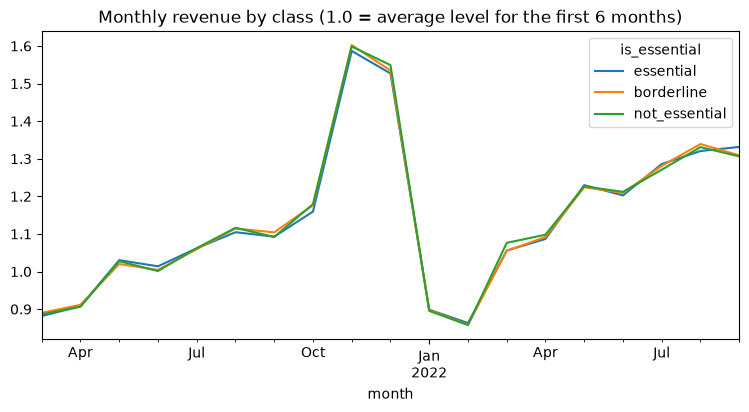

In [16]:
cm = (spark.read.parquet("../data/curated/final_external_enriched")
      .groupBy("merchant_abn", F.date_trunc("month", "order_datetime").alias("month"))
      .agg(F.sum("dollar_value").alias("rev"))
      .toPandas()
      .merge(ess, on="merchant_abn"))

trend = cm.groupby(["month", "is_essential"])["rev"].sum().unstack().iloc[1:-1]  
trend = trend / trend.iloc[:6].mean()      # 1.0 = average level for the first 6 months
trend[["essential", "borderline", "not_essential"]].plot(figsize=(9, 4),
      title="Monthly revenue by class (1.0 = average level for the first 6 months)")

The monthly revenue in each class is approximately the same for all cases. Therefore, we can't determine whether this feature can be used as planned. However, we will keep `is_essential` as a business decision, since we consider that consumers will keep buying essential products, regardless of circumstances, so their demand is expected to be more stable.

# Demographics
We will determine the demographic features that we will use for merchants.

In [17]:
# bring consumer_features 
cf = spark.read.parquet("../data/curated/consumer_features")
tag_cols = ["consumer_id", "advantage_area", "socioeconomic_area", "age_area_tag",
            "mortgage_cost_tag", "poa_irsad_decile", "poa_irsd_decile"]
print("Missing in the table:", [c for c in tag_cols if c not in cf.columns])
tags_pd = cf.select(*[c for c in tag_cols if c in cf.columns]).toPandas()

cm = (spark.read.parquet("../data/curated/final_external_enriched")
      .groupBy("consumer_id")
      .agg(F.sum(F.col("take_rate") / 100 * F.col("dollar_value")).alias("est_revenue"),
           F.count("*").alias("transaction_count"),
           F.expr("percentile_approx(dollar_value, 0.5)").alias("median_transaction"))
      .toPandas())

cm["consumer_id"] = cm["consumer_id"].astype(str)
tags_pd["consumer_id"] = tags_pd["consumer_id"].astype(str)
cf2 = cm.merge(tags_pd, on="consumer_id", how="left")

print(len(cm), "consumers in final_external_enriched |", len(tags_pd), "in consumer_features")
print("Missing label:", cf2["advantage_area"].isna().sum())
print(cf2.isna().mean().round(3))

Missing in the table: []


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


24081 consumers in final_external_enriched | 24081 in consumer_features
Missing label: 0
consumer_id           0.000
est_revenue           0.000
transaction_count     0.000
median_transaction    0.000
advantage_area        0.000
socioeconomic_area    0.000
age_area_tag          0.000
mortgage_cost_tag     0.000
poa_irsad_decile      0.171
poa_irsd_decile       0.171
dtype: float64


In [18]:
# see other census columns that are available in the final_external_enriched table
census_cols = ["Median_tot_prsnl_inc_weekly", "Median_rent_weekly", "Median_tot_fam_inc_weekly",
               "Average_num_psns_per_bedroom", "Median_tot_hhd_inc_weekly", "Average_household_size",
               "prop_18_34", "poa_population", "Median_age_persons", "Median_mortgage_repay_monthly"]

enr = spark.read.parquet("../data/curated/final_external_enriched")
have = [c for c in census_cols if c in enr.columns]
print("Missing from the table:", [c for c in census_cols if c not in enr.columns])

area = enr.groupBy("consumer_id").agg(*[F.first(c, ignorenulls=True).alias(c) for c in have]).toPandas()
area["consumer_id"] = area["consumer_id"].astype(str)

base = cf2[["consumer_id", "est_revenue", "transaction_count", "median_transaction"]]
d = base.merge(area, on="consumer_id", how="left")

outcomes = ["est_revenue", "transaction_count", "median_transaction"]
rho = d[have + outcomes].corr(method="spearman").loc[have, outcomes].round(3)
print(rho)
print("noise level (about 2 standard errors):", round(2 / np.sqrt(d[have[0]].notna().sum()), 3))

Missing from the table: []


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


                               est_revenue  transaction_count  \
Median_tot_prsnl_inc_weekly          0.006              0.011   
Median_rent_weekly                   0.000             -0.004   
Median_tot_fam_inc_weekly            0.003              0.006   
Average_num_psns_per_bedroom         0.006              0.008   
Median_tot_hhd_inc_weekly            0.006              0.006   
Average_household_size               0.008             -0.001   
prop_18_34                          -0.011              0.008   
poa_population                      -0.005             -0.004   
Median_age_persons                   0.010             -0.009   
Median_mortgage_repay_monthly        0.001             -0.002   

                               median_transaction  
Median_tot_prsnl_inc_weekly                 0.010  
Median_rent_weekly                          0.003  
Median_tot_fam_inc_weekly                   0.006  
Average_num_psns_per_bedroom                0.006  
Median_tot_hhd_inc_weekl

In [19]:
import numpy as np

need = ["Median_age_persons", "Median_mortgage_repay_monthly"]
print("Missing in cf:", [c for c in need if c not in cf.columns])
extra = cf.select("consumer_id", *[c for c in need if c in cf.columns]).toPandas()
extra["consumer_id"] = extra["consumer_id"].astype(str)
cf2 = cf2.merge(extra, on="consumer_id", how="left")

# the tags use .otherwise(), so a missing source value fell into the last group
for tag, src in [("advantage_area", "poa_irsad_decile"),
                 ("socioeconomic_area", "poa_irsd_decile"),
                 ("age_area_tag", "Median_age_persons"),
                 ("mortgage_cost_tag", "Median_mortgage_repay_monthly")]:
    cf2.loc[cf2[src].isna(), tag] = np.nan
    print(f"{tag:20s} unknown: {cf2[tag].isna().sum()} ({cf2[tag].isna().mean():.1%})")

Missing in cf: []
advantage_area       unknown: 4121 (17.1%)
socioeconomic_area   unknown: 4121 (17.1%)
age_area_tag         unknown: 3970 (16.5%)
mortgage_cost_tag    unknown: 3977 (16.5%)


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [20]:
def compare_groups(df, col, order):
    d = df.copy()
    d[col] = d[col].fillna("Unknown")
    g = d.groupby(col).agg(
        consumers=("consumer_id", "count"),
        revenue=("est_revenue", "sum"),
        transactions=("transaction_count", "sum"),
        revenue_median=("est_revenue", "median"),
        tx_median=("transaction_count", "median"),
        ticket_median=("median_transaction", "median"),
    )
    g = g.reindex([o for o in order + ["Unknown"] if o in g.index])
    share = lambda c: g[c] / g[c].sum() * 100
    g["pct_consumers"]      = share("consumers")
    g["revenue_index"]      = share("revenue") / g["pct_consumers"]       # more revenue than its share
    g["demand_index"]       = share("transactions") / g["pct_consumers"]  # buys more often
    g["value_per_tx_index"] = g["revenue_index"] / g["demand_index"]      # worth more per purchase
    return g.round(2)

tags = {
    "advantage_area":     ["Lower Advantage", "Middle", "Higher Advantage"],
    "socioeconomic_area": ["Higher Disadvantage", "Middle", "Lower Disadvantage"],
    "age_area_tag":       ["Younger Area", "Middle-age Area", "Older Area"],
    "mortgage_cost_tag":  ["Lower Mortgage Cost Area", "Middle Mortgage Cost Area", "Higher Mortgage Cost Area"],
}
tables = {}
for col, order in tags.items():
    tables[col] = compare_groups(cf2, col, order)
    print(f"\n=== {col} ===")
    print(tables[col][["consumers", "pct_consumers", "revenue_median", "tx_median",
                       "ticket_median", "revenue_index", "demand_index"]])


=== advantage_area ===
                  consumers  pct_consumers  revenue_median  tx_median  \
advantage_area                                                          
Lower Advantage        6106          25.36         3928.43      565.0   
Middle                 7876          32.71         3931.38      564.0   
Higher Advantage       5978          24.82         3932.61      564.0   
Unknown                4121          17.11         3935.81      564.0   

                  ticket_median  revenue_index  demand_index  
advantage_area                                                
Lower Advantage           60.84            1.0           1.0  
Middle                    60.81            1.0           1.0  
Higher Advantage          60.84            1.0           1.0  
Unknown                   60.84            1.0           1.0  

=== socioeconomic_area ===
                     consumers  pct_consumers  revenue_median  tx_median  \
socioeconomic_area                                     

In all cases, we can see how the revenue and the median ticket do not differ across groups. This suggests that demographic indicators may not rank merchants as intended. To further analyse this, we do the following plot.

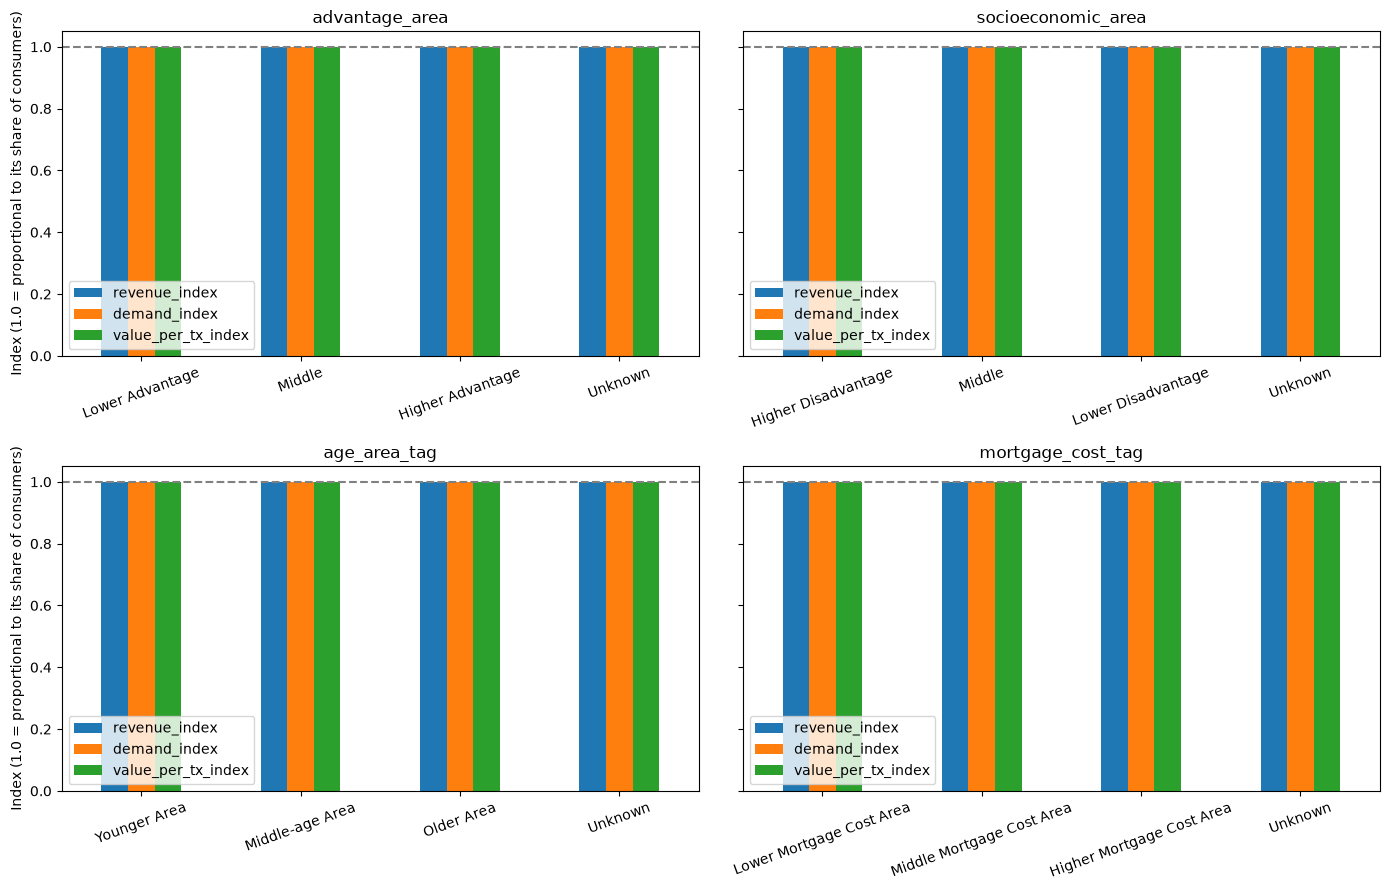

advantage_area → max difference between groups: {'revenue_index': 0.0, 'demand_index': 0.0}
socioeconomic_area → max difference between groups: {'revenue_index': 0.0, 'demand_index': 0.0}
age_area_tag → max difference between groups: {'revenue_index': 0.0, 'demand_index': 0.0}
mortgage_cost_tag → max difference between groups: {'revenue_index': 0.0, 'demand_index': 0.0}


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
for ax, (col, t) in zip(axes.flatten(), tables.items()):
    t[["revenue_index", "demand_index", "value_per_tx_index"]].plot.bar(ax=ax, rot=20)
    ax.axhline(1.0, color="grey", linestyle="--")
    ax.set_title(col); ax.set_xlabel("")
for ax in axes[:, 0]:
    ax.set_ylabel("Index (1.0 = proportional to its share of consumers)")
plt.tight_layout(); plt.show()

for col, t in tables.items():
    k = t.drop(index="Unknown", errors="ignore")[["revenue_index", "demand_index"]]
    print(col, "→ max difference between groups:", (k.max() - k.min()).round(2).to_dict())

The result is the same, no matter the group, which aligns with what was seen before.

In [22]:
ad = cf.select("consumer_id", "transaction_count", "active_days").toPandas()
ad["consumer_id"] = ad["consumer_id"].astype(str)
ad = ad[ad["transaction_count"] >= 5].copy()
ad["tx_per_30d"] = ad["transaction_count"] / ad["active_days"] * 30

x = cf2[["consumer_id", "age_area_tag"]].merge(ad, on="consumer_id")
print(x.groupby("age_area_tag")["tx_per_30d"].agg(["count", "mean", "median"]).round(2))

                 count   mean  median
age_area_tag                         
Middle-age Area   6840  29.26   29.21
Older Area        6738  29.25   29.21
Younger Area      6533  29.26   29.21


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


We can also observe that the ticket price per month is similar across ages.

                  consumers  revenue_median  tx_median
poa_irsad_decile                                      
1.0                    1989          3903.1      565.0
2.0                    2079          3950.7      565.0
3.0                    2038          3928.2      565.0
4.0                    1964          3926.0      564.0
5.0                    1993          3926.7      564.0
6.0                    2022          3929.6      564.0
7.0                    1897          3942.4      565.0
8.0                    2002          3921.1      564.0
9.0                    1990          3938.8      564.0
10.0                   1986          3932.0      565.0


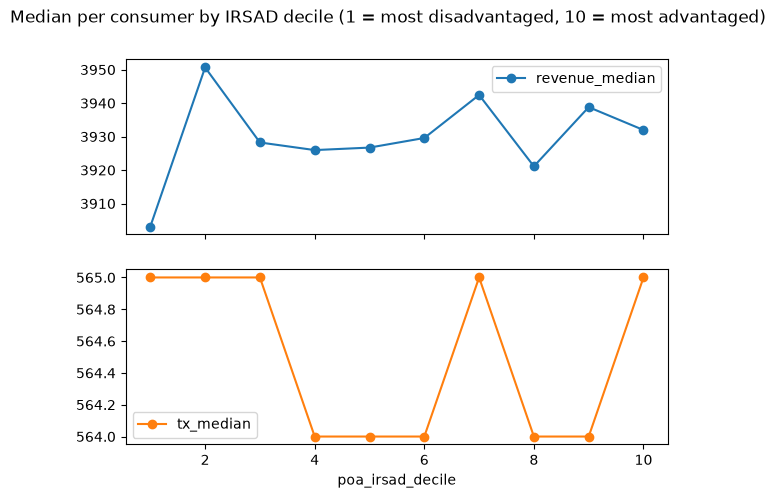

In [23]:
dec = (cf2.dropna(subset=["poa_irsad_decile"])
          .groupby("poa_irsad_decile")
          .agg(consumers=("consumer_id", "count"),
               revenue_median=("est_revenue", "median"),
               tx_median=("transaction_count", "median")))
print(dec.round(1))
dec[["revenue_median", "tx_median"]].plot(subplots=True, marker="o", figsize=(7, 5),
    title="Median per consumer by IRSAD decile (1 = most disadvantaged, 10 = most advantaged)")
plt.show()


There is no clear pattern to determine whether more disadvantage or more advantage actually has an effect on the median ticket and revenue.

In [24]:
ad = cf.select("consumer_id", "active_days", "transaction_count").toPandas()
print(ad[["active_days", "transaction_count"]].describe().round(0))
print("share with 365+ active days:", round((ad["active_days"] >= 365).mean() * 100, 1), "%")

       active_days  transaction_count
count      24081.0            24081.0
mean         605.0              589.0
std            2.0               10.0
min          590.0              568.0
25%          604.0              582.0
50%          605.0              588.0
75%          606.0              596.0
max          606.0              620.0
share with 365+ active days: 100.0 %


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [25]:
# see how revenue per consumer changes before and after may 2022
mm = (spark.read.parquet("../data/curated/final_external_enriched")
      .withColumn("month", F.date_trunc("month", "order_datetime"))
      .groupBy("consumer_id", "month")
      .agg(F.sum(F.col("take_rate") / 100 * F.col("dollar_value")).alias("rev"))
      .toPandas())
mm["consumer_id"] = mm["consumer_id"].astype(str)
mm["month"] = pd.to_datetime(mm["month"])
mm = mm[(mm["month"] > mm["month"].min()) & (mm["month"] < mm["month"].max())]  # drop incomplete months
mm["period"] = np.where(mm["month"] >= "2022-05-01", "after", "before")
mm = mm.merge(cf2[["consumer_id", "mortgage_cost_tag"]], on="consumer_id")

res = mm.groupby(["mortgage_cost_tag", "period"])["rev"].mean().unstack()
res["after / before"] = (res["after"] / res["before"]).round(3)
print(res.round(3))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


period                       after   before  after / before
mortgage_cost_tag                                          
Higher Mortgage Cost Area  222.670  190.942           1.166
Lower Mortgage Cost Area   221.472  191.919           1.154
Middle Mortgage Cost Area  221.973  191.300           1.160


Consumers behave similarly to each other, regardless of the demographic indicator.

In [26]:
# check how revenue per merchant changes before and after may 2022
# see if the growth is correlated (Spearman) for merchants with above-median revenue
mrev = (spark.read.parquet("../data/curated/final_external_enriched")
        .withColumn("month", F.date_format("order_datetime", "yyyy-MM"))
        .groupBy("merchant_abn", "month").agg(F.sum("dollar_value").alias("rev"))
        .toPandas())
mrev["merchant_abn"] = mrev["merchant_abn"].astype(str)
w = mrev.pivot(index="merchant_abn", columns="month", values="rev").fillna(0)

def wsum(months): return w[[m for m in months if m in w.columns]].sum(axis=1)
A21, A22 = wsum(["2021-03", "2021-04"]), wsum(["2022-03", "2022-04"])
B21 = wsum([f"2021-{m:02d}" for m in range(5, 10)])
B22 = wsum([f"2022-{m:02d}" for m in range(5, 10)])

g = pd.DataFrame({"growth_before": A22 / A21 - 1, "growth_after": B22 / B21 - 1, "rev_base": A21 + B21})
g = g.replace([np.inf, -np.inf], np.nan).dropna()
big = g[g["rev_base"] >= g["rev_base"].median()]
for name, d in [("all", g), ("above-median revenue", big)]:
    print(name, len(d), "merchants | Spearman growth before vs after:",
          round(d[["growth_before", "growth_after"]].corr(method="spearman").iloc[0, 1], 3))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


all 3827 merchants | Spearman growth before vs after: 0.014
above-median revenue 1914 merchants | Spearman growth before vs after: 0.016


In the notebook 06_modelling.ipynb, it was seen that after May 2022, there is an increase in the RBA Cash Rate. However, in the case we can see that a merchant who grew before the increase of RBA rate, does not grow after.

In [27]:
# check how many consumers have more than one gender value in the final_external_enriched table
gen = (spark.read.parquet("../data/curated/final_external_enriched")
       .groupBy("consumer_id")
       .agg(F.first("gender", ignorenulls=True).alias("gender"),
            F.countDistinct("gender").alias("n_gender_values"))
       .toPandas())
gen["consumer_id"] = gen["consumer_id"].astype(str)
print("consumers with more than one gender value:", (gen["n_gender_values"] > 1).sum())

cf2 = cf2.drop(columns=["gender"], errors="ignore").merge(gen[["consumer_id", "gender"]], on="consumer_id", how="left")
print(cf2["gender"].value_counts(dropna=False))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


consumers with more than one gender value: 0
gender
Male           10931
Female         10703
Undisclosed     2447
Name: count, dtype: int64


In [28]:
gender_order = list(cf2["gender"].dropna().unique())
gender_table = compare_groups(cf2, "gender", gender_order)
print(gender_table[["consumers", "pct_consumers", "revenue_median", "tx_median",
                    "ticket_median", "revenue_index", "demand_index"]])

# real difference between groups vs the difference you get by chance (labels shuffled)
def spread(df, v):
    med = df.dropna(subset=["gender"]).groupby("gender")[v].median()
    return (med.max() - med.min()) / med.mean() * 100

shuf = cf2.assign(gender=np.random.default_rng(0).permutation(cf2["gender"].values))
for v in ["est_revenue", "transaction_count", "median_transaction"]:
    print(f"{v:20s} spread between genders: {spread(cf2, v):.2f}% | by chance (shuffled): {spread(shuf, v):.2f}%")

             consumers  pct_consumers  revenue_median  tx_median  \
gender                                                             
Female           10703          44.45         3928.39      564.0   
Undisclosed       2447          10.16         3948.62      565.0   
Male             10931          45.39         3929.62      565.0   

             ticket_median  revenue_index  demand_index  
gender                                                   
Female               60.78            1.0           1.0  
Undisclosed          60.97            1.0           1.0  
Male                 60.84            1.0           1.0  
est_revenue          spread between genders: 0.51% | by chance (shuffled): 0.21%
transaction_count    spread between genders: 0.18% | by chance (shuffled): 0.18%
median_transaction   spread between genders: 0.31% | by chance (shuffled): 0.15%


Revenue and median ticket are similar, regardless of the gender.

In [29]:
rows = []
for col in tags:
    d = cf2.assign(area=cf2[col].fillna("Unknown"))
    for metric in ["est_revenue", "transaction_count"]:
        t = d.pivot_table(index="area", columns="gender", values=metric, aggfunc="median")
        s = (t.max(axis=1) - t.min(axis=1)) / t.mean(axis=1) * 100
        for area, v in s.items():
            rows.append({"tag": col, "area": area, "metric": metric, "gender_spread_%": round(v, 2)})

area_spread = pd.DataFrame(rows).pivot_table(index=["tag", "area"], columns="metric", values="gender_spread_%")
print(area_spread)
print("largest spread:", area_spread.max().round(2).to_dict())

metric                                        est_revenue  transaction_count
tag                area                                                     
advantage_area     Higher Advantage                  0.28               0.18
                   Lower Advantage                   1.38               0.18
                   Middle                            0.09               0.18
                   Unknown                           1.26               0.00
age_area_tag       Middle-age Area                   0.49               0.00
                   Older Area                        1.17               0.18
                   Unknown                           1.26               0.00
                   Younger Area                      0.44               0.18
mortgage_cost_tag  Higher Mortgage Cost Area         0.42               0.18
                   Lower Mortgage Cost Area          1.13               0.18
                   Middle Mortgage Cost Area         0.31               0.00

In [30]:
cols = ["consumer_id"] + list(tags)
tag_sp = spark.createDataFrame(cf2[cols].fillna("Unknown").astype(str).values.tolist(), cols)

tx = (spark.read.parquet("../data/curated/final_external_enriched")
      .select("merchant_abn", F.col("consumer_id").cast("string").alias("consumer_id"))
      .join(tag_sp, on="consumer_id", how="inner"))

targets = {"socioeconomic_area": "Higher Disadvantage", "advantage_area": "Lower Advantage",
           "age_area_tag": "Younger Area", "mortgage_cost_tag": "Higher Mortgage Cost Area"}
aggs = []
for c, label in targets.items():
    aggs += [F.sum((F.col(c) == label).cast("int")).alias(f"{c}_hit"),
             F.sum((F.col(c) != "Unknown").cast("int")).alias(f"{c}_known")]

mix = tx.groupBy("merchant_abn").agg(F.count("*").alias("n_tx"), *aggs).toPandas()
mix["merchant_abn"] = mix["merchant_abn"].astype(str)
mix = mix[mix["n_tx"] >= 30]

for c in targets:
    p = mix[f"{c}_hit"].sum() / mix[f"{c}_known"].sum()
    share = mix[f"{c}_hit"] / mix[f"{c}_known"]
    mix[f"z_{c}"] = ((share - p) / np.sqrt(p * (1 - p) / mix[f"{c}_known"])).replace([np.inf, -np.inf], np.nan)
    print(f"{c:20s} overall share {p:.1%} | std of z = {mix[f'z_{c}'].std():.2f}")

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


socioeconomic_area   overall share 30.5% | std of z = 0.98
advantage_area       overall share 30.6% | std of z = 0.99
age_area_tag         overall share 32.5% | std of z = 1.00
mortgage_cost_tag    overall share 33.0% | std of z = 1.02


# Demographics at a merchant level
The analysis above shows how consumers behave the same regardless of the criteria that we use. However, the results of merchants may still differ, since some may attract young customers or customers from disadvantaged areas.

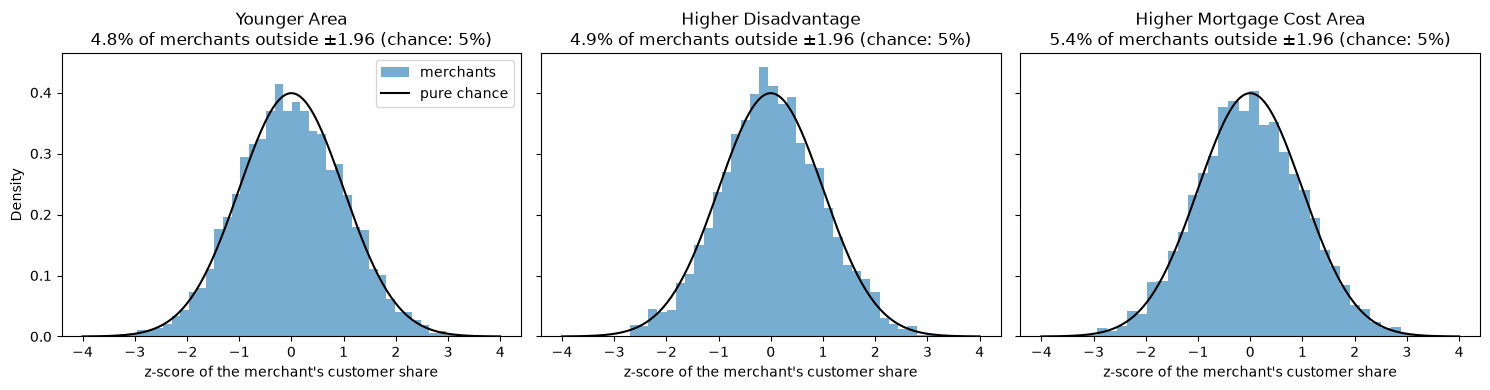

In [31]:
RULES = {
    "age_area_tag": "Younger Area",
    "socioeconomic_area": "Higher Disadvantage",
    "mortgage_cost_tag": "Higher Mortgage Cost Area",
}

# standard normal curve = what pure chance looks like
x = np.linspace(-4, 4, 200)
normal_pdf = np.exp(-x ** 2 / 2) / np.sqrt(2 * np.pi)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (col, label) in zip(axes, RULES.items()):
    z = mix[f"z_{col}"].dropna()
    ax.hist(z, bins=40, density=True, alpha=0.6, label="merchants")
    ax.plot(x, normal_pdf, color="black", label="pure chance")
    ax.set_title(f"{label}\n{(z.abs() > 1.96).mean():.1%} of merchants outside ±1.96 (chance: 5%)")
    ax.set_xlabel("z-score of the merchant's customer share")
axes[0].set_ylabel("Density")
axes[0].legend()
plt.tight_layout()
plt.show()

The type of consumers that merchants attract are similar in all cases. Hence, a merchant doesn't have a specific type of consumer.

In [32]:
# Is the customer mix related to merchant performance?
perf = mix.merge(
    rankings_pd[["merchant_abn", "est_revenue", "num_transactions", "avg_ticket"]],
    on="merchant_abn", how="inner",
)
rho = {}
for col, label in RULES.items():
    share = perf[f"{col}_hit"] / perf[f"{col}_known"]
    rho[label] = {m: share.corr(perf[m], method="spearman")
                  for m in ["est_revenue", "num_transactions", "avg_ticket"]}

print("Spearman correlation between the merchant's customer share and its performance:")
print(pd.DataFrame(rho).T.round(3))
print("Noise level (about 2 standard errors):", round(2 / np.sqrt(len(perf)), 3))

Spearman correlation between the merchant's customer share and its performance:
                           est_revenue  num_transactions  avg_ticket
Younger Area                    -0.013             0.013      -0.021
Higher Disadvantage              0.003            -0.004       0.007
Higher Mortgage Cost Area       -0.008             0.013      -0.018
Noise level (about 2 standard errors): 0.033


There is no correlation between the merchants and the type of consumer.

In [33]:
# Do the best merchants by revenue have a different customer mix?
top100_rev = set(rankings_pd.nlargest(100, "est_revenue")["merchant_abn"])
perf["in_top100"] = perf["merchant_abn"].isin(top100_rev)

comp = {}
for col, label in RULES.items():
    g = perf.groupby("in_top100")[[f"{col}_hit", f"{col}_known"]].sum()
    comp[label] = (g[f"{col}_hit"] / g[f"{col}_known"] * 100).round(2)

print(pd.DataFrame(comp).T.rename(columns={False: "other merchants (%)",
                                           True: "top 100 by revenue (%)"}))

in_top100                  other merchants (%)  top 100 by revenue (%)
Younger Area                             32.47                   32.52
Higher Disadvantage                      30.56                   30.52
Higher Mortgage Cost Area                32.96                   33.00


Hence demographic statistics don't affect the revenue results of BNPL and the merchants statistics. However, we have decided to keep them, because BNPL can benefit from "young and low-income demographics [1]." Therefore, in general, we will consider that when a consumer is younger and purchases in an area with higher disadvantage in socioeconomic aspects and a lower advantage, then this is a merchant that will benefit the company.

In addition to this, when the mortgage rate is higher, then people will struggle more to pay. Although these are business considerations, they will be kept for the ranking, since, in a general case, demographics would affect the real results.

# Minimum number of transactions
We will not consider merchants with few transactions, since this may lead to unreliable resutls.

In [34]:
m_monthly = (
    spark.read.parquet("../data/curated/final_external_enriched")
    .groupBy("merchant_abn", F.date_trunc("month", "order_datetime").alias("month"))
    .agg(F.sum("dollar_value").alias("rev"))
    .toPandas()
)
m_monthly["merchant_abn"] = m_monthly["merchant_abn"].astype(str)
wide_all = (m_monthly.pivot(index="merchant_abn", columns="month", values="rev")
            .fillna(0).sort_index(axis=1))

mt = rankings_pd[["merchant_abn", "num_transactions", "est_revenue"]].copy()
mt["active_months"] = mt["merchant_abn"].map((wide_all > 0).sum(axis=1))

# coefficient of variation of monthly revenue; months without sales count as 0,
# and the incomplete first and last months are dropped
wide = wide_all.iloc[:, 1:-1]
cv_all = (wide.std(axis=1) / wide.mean(axis=1)).replace([np.inf, -np.inf], np.nan)
mt["monthly_cv"] = mt["merchant_abn"].map(cv_all)

print(mt[["num_transactions", "active_months"]]
      .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5]).round(0))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


       num_transactions  active_months
count            4026.0         4026.0
mean             3382.0           19.0
std             14147.0            4.0
min                 1.0            1.0
1%                  3.0            3.0
5%                 12.0            9.0
10%                27.0           15.0
25%                93.0           20.0
50%               418.0           20.0
max            289513.0           21.0


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


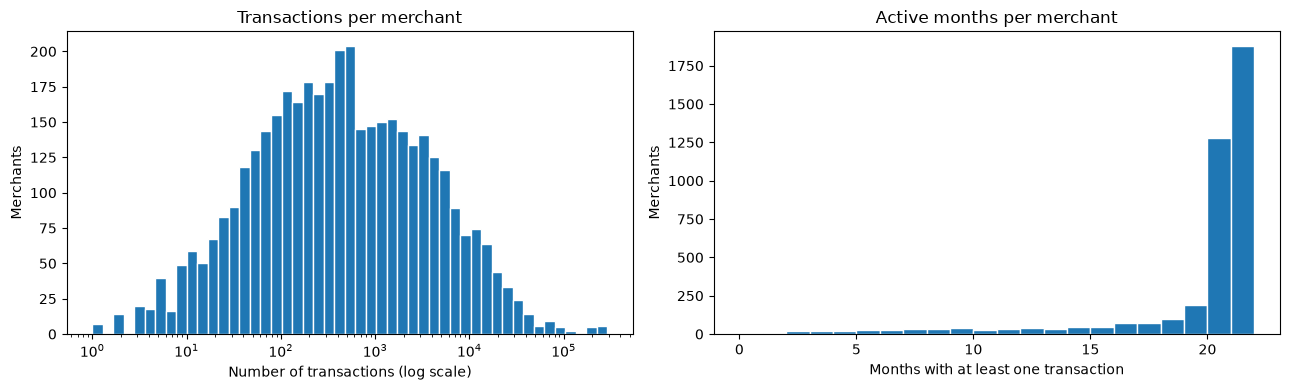

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.logspace(0, np.log10(mt["num_transactions"].max()), 50)
axes[0].hist(mt["num_transactions"], bins=bins, edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_xlabel("Number of transactions (log scale)")
axes[0].set_ylabel("Merchants")
axes[0].set_title("Transactions per merchant")

axes[1].hist(mt["active_months"], bins=range(0, int(mt["active_months"].max()) + 2), edgecolor="white")
axes[1].set_xlabel("Months with at least one transaction")
axes[1].set_ylabel("Merchants")
axes[1].set_title("Active months per merchant")
plt.tight_layout()
plt.show()

                 merchants  median_cv  median_active_months
tx_band                                                    
[0.0, 5.0)              59       3.11                   3.0
[5.0, 10.0)             85       2.02                   6.0
[10.0, 20.0)           172       1.41                  10.0
[20.0, 30.0)           124       1.09                  14.0
[30.0, 50.0)           218       0.87                  17.0
[50.0, 75.0)           214       0.70                  19.0
[75.0, 100.0)          180       0.59                  20.0
[100.0, 150.0)         268       0.51                  20.0
[150.0, 200.0)         187       0.43                  20.0
[200.0, 300.0)         274       0.38                  20.0
[300.0, 500.0)         397       0.33                  20.0
[500.0, 1000.0)        435       0.27                  21.0
[1000.0, inf)         1413       0.20                  21.0


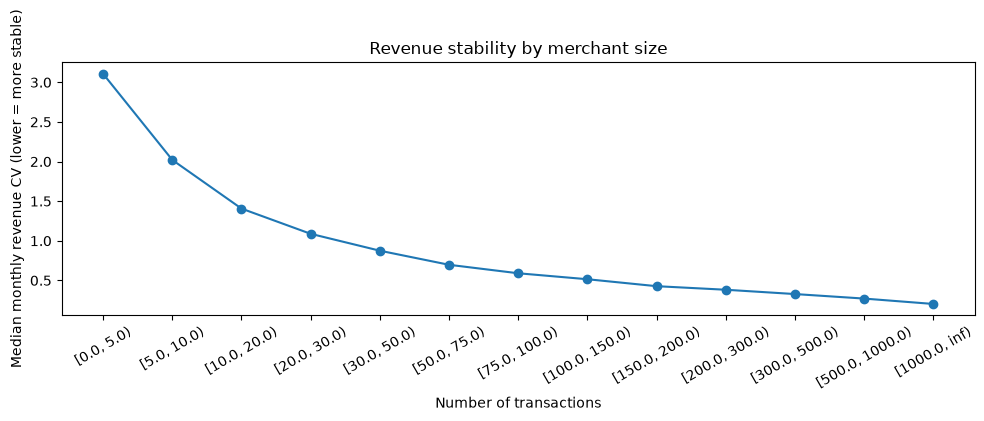

In [36]:
# Where do merchant metrics become stable?
edges = [0, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500, 1000, np.inf]
mt["tx_band"] = pd.cut(mt["num_transactions"], edges, right=False)
cv_by_band = mt.groupby("tx_band", observed=True).agg(
    merchants=("merchant_abn", "count"),
    median_cv=("monthly_cv", "median"),
    median_active_months=("active_months", "median"),
)
print(cv_by_band.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(cv_by_band)), cv_by_band["median_cv"], marker="o")
ax.set_xticks(range(len(cv_by_band)))
ax.set_xticklabels([str(b) for b in cv_by_band.index], rotation=30)
ax.set_xlabel("Number of transactions")
ax.set_ylabel("Median monthly revenue CV (lower = more stable)")
ax.set_title("Revenue stability by merchant size")
plt.tight_layout()
plt.show()

In [37]:
# What does each possible minimum cost?
total_rev = mt["est_revenue"].sum()
revenue_rank = mt["est_revenue"].rank(ascending=False)

rows = []
for t in [5, 10, 20, 30, 50, 75, 100]:
    out = mt["num_transactions"] < t
    rows.append({
        "min_transactions": t,
        "merchants_excluded": int(out.sum()),
        "pct_merchants": round(out.mean() * 100, 1),
        "pct_est_revenue_lost": round(mt.loc[out, "est_revenue"].sum() / total_rev * 100, 2),
        "best_revenue_rank_excluded": int(revenue_rank[out].min()) if out.any() else None,
    })
print(pd.DataFrame(rows).to_string(index=False))

 min_transactions  merchants_excluded  pct_merchants  pct_est_revenue_lost  best_revenue_rank_excluded
                5                  59            1.5                  0.09                        2040
               10                 144            3.6                  0.21                        1702
               20                 316            7.8                  0.57                        1250
               30                 440           10.9                  0.91                         935
               50                 658           16.3                  1.51                         650
               75                 872           21.7                  2.42                         437
              100                1052           26.1                  3.53                         173


  We will set the minimum at 30 transactions, since the stability plot shows that merchants with few transactions have irregular revenue (most months have no sales). In addition to this, from the ranking we can see that none of the merchants that will be removed rank higher than position 935.

# Fraud
The `is_fraud` label was built in `models/01`–`03`.

In [38]:
THRESHOLD_MERCHANT = (53.286933 + 61.923809) / 2   # same threshold as models/01_Label_merchants

mf = (
    spark.read.parquet("../data/curated/transactions_with_is_fraud_full")
    .groupBy("merchant_abn")
    .agg(
        F.max("is_fraud_merchant").alias("is_fraud_merchant"),          # 1 / 0 / null
        F.max("avg_merchant_fraud_prob").alias("observed_fraud_prob"),  # real data
        F.count("*").alias("n_tx"),
        F.sum(F.col("is_fraud_consumer").isNotNull().cast("int")).alias("consumer_labelled"),
        F.sum((F.col("is_fraud_consumer") == 1).cast("int")).alias("consumer_fraud"),
    )
    .toPandas()
)
mf["merchant_abn"] = mf["merchant_abn"].astype(str)
mf = mf.merge(rankings_pd[["merchant_abn", "est_revenue", "num_transactions", "avg_ticket"]],
              on="merchant_abn", how="inner")

mf["merchant_label"] = (mf["is_fraud_merchant"]
                        .map({1.0: "flagged as fraud", 0.0: "not fraud"}).fillna("no label"))
mf["observed_fraud"] = mf["observed_fraud_prob"] > THRESHOLD_MERCHANT   # NaN -> False

print("Merchants:", len(mf))
print(mf["merchant_label"].value_counts())
print("Merchants with a real fraud probability above the threshold:", int(mf["observed_fraud"].sum()))

/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Merchants: 4026
merchant_label
no label            2122
flagged as fraud     955
not fraud            949
Name: count, dtype: int64
Merchants with a real fraud probability above the threshold: 17


                  est_revenue  num_transactions  avg_ticket
merchant_label                                             
flagged as fraud       6546.7             357.0       361.8
not fraud             45314.1            2700.0       369.8
no label               1647.7             134.0       239.3


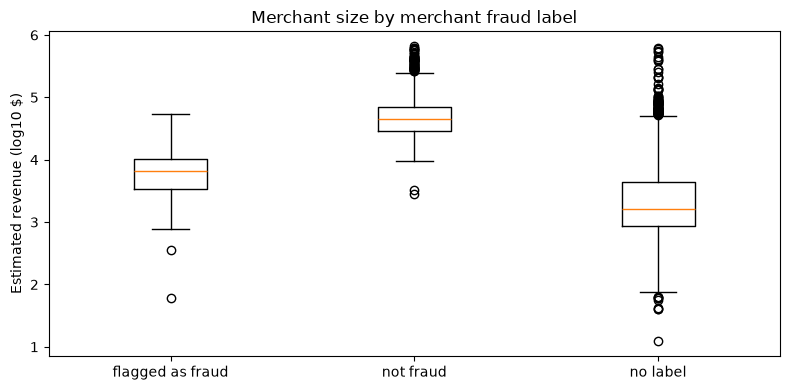

Top 100 merchants by revenue, by merchant label:
merchant_label
not fraud    85
no label     15
Name: count, dtype: int64


In [39]:
# Is the merchant label just a proxy for merchant size?
label_order = ["flagged as fraud", "not fraud", "no label"]
print(mf.groupby("merchant_label")[["est_revenue", "num_transactions", "avg_ticket"]]
      .median().reindex(label_order).round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([np.log10(mf.loc[mf["merchant_label"] == g, "est_revenue"]) for g in label_order])
ax.set_xticks(range(1, len(label_order) + 1))
ax.set_xticklabels(label_order)
ax.set_ylabel("Estimated revenue (log10 $)")
ax.set_title("Merchant size by merchant fraud label")
plt.tight_layout()
plt.show()

top100_rev = set(rankings_pd.nlargest(100, "est_revenue")["merchant_abn"])
print("Top 100 merchants by revenue, by merchant label:")
print(mf[mf["merchant_abn"].isin(top100_rev)]["merchant_label"].value_counts())

Revenue is higher for the cases of not fraud

In [40]:
# Merchants with REAL fraud above the threshold: where would they rank by revenue?
rev_rank = rankings_pd.set_index("merchant_abn")["est_revenue"].rank(ascending=False)
obs = mf[mf["observed_fraud"]]
print("Revenue rank of merchants with observed fraud:",
      sorted(rev_rank.loc[obs["merchant_abn"]].astype(int).tolist()))

Revenue rank of merchants with observed fraud: [453, 458, 521, 765, 877, 1421, 2119, 2166, 2506, 2546, 2584, 2719, 2735, 2968, 2979, 3925, 4021]


In [41]:
# Consumer side: how much label information does each merchant have?
mf["consumer_coverage"] = mf["consumer_labelled"] / mf["n_tx"]
mf["consumer_fraud_rate"] = mf["consumer_fraud"] / mf["consumer_labelled"].replace(0, np.nan)

print(mf[["consumer_labelled", "consumer_coverage", "consumer_fraud_rate"]]
      .describe(percentiles=[0.10, 0.25, 0.5, 0.75, 0.90]).round(4))
print("Merchants with no labelled consumer transactions:", int((mf["consumer_labelled"] == 0).sum()))
print("Merchants with fewer than 30 labelled consumer transactions:", int((mf["consumer_labelled"] < 30).sum()))

       consumer_labelled  consumer_coverage  consumer_fraud_rate
count          4026.0000          4026.0000            4016.0000
mean            182.2710             0.2341               0.0243
std             480.4004             0.2658               0.1072
min               0.0000             0.0000               0.0000
10%               5.0000             0.0198               0.0000
25%              11.0000             0.0237               0.0000
50%              39.0000             0.1004               0.0000
75%             180.7500             0.4175               0.0034
90%             410.0000             0.6752               0.0184
max            6275.0000             1.0000               1.0000
Merchants with no labelled consumer transactions: 10
Merchants with fewer than 30 labelled consumer transactions: 1836


               median_ticket  consumer_fraud_rate
ticket_decile                                    
1                    39.2544               0.0094
2                    84.7673               0.0096
3                   118.1111               0.0093
4                   186.2562               0.0054
5                   269.9040               0.0029
6                   372.0507               0.0016
7                   503.9493               0.0010
8                   836.3149               0.0005
9                  1604.2611               0.0012
10                 4313.2950               0.0971
Spearman avg_ticket vs consumer fraud rate: -0.088


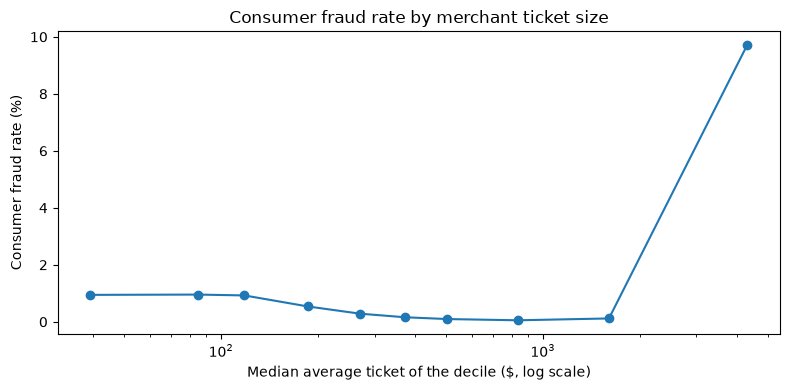

top 100 by revenue   consumer fraud rate: 0.60%
other merchants      consumer fraud rate: 0.80%


In [42]:
# The consumer fraud model learnt mostly from dollar value.
# Does that make the consumer fraud rate a proxy for ticket size?
mf["ticket_decile"] = pd.qcut(mf["avg_ticket"], 10, labels=False) + 1
g = mf.groupby("ticket_decile")
by_ticket = pd.DataFrame({
    "median_ticket": g["avg_ticket"].median(),
    "consumer_fraud_rate": g["consumer_fraud"].sum() / g["consumer_labelled"].sum(),
})
print(by_ticket.round(4))
print("Spearman avg_ticket vs consumer fraud rate:",
      round(mf["avg_ticket"].corr(mf["consumer_fraud_rate"], method="spearman"), 3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_ticket["median_ticket"], by_ticket["consumer_fraud_rate"] * 100, marker="o")
ax.set_xscale("log")
ax.set_xlabel("Median average ticket of the decile ($, log scale)")
ax.set_ylabel("Consumer fraud rate (%)")
ax.set_title("Consumer fraud rate by merchant ticket size")
plt.tight_layout()
plt.show()

in_top = mf["merchant_abn"].isin(top100_rev)
for name, d in [("top 100 by revenue", mf[in_top]), ("other merchants", mf[~in_top])]:
    print(f"{name:20s} consumer fraud rate: {d['consumer_fraud'].sum() / d['consumer_labelled'].sum():.2%}")

Consumer fraud is concentrated among those with higher purchases. The top 100 merchants have a slightly lower fraud rate than the rest.

For our ranking, we will treat is_fraud as follows:
- We will exclude those merchants with observed fraud, meaning that they had an actual high fraud probability.
- Merchants who are flagged will be penalised, but not excluded since our model was only trained on 48 merchants and it mostly learned from the revenue.
- Consumer fraud rate will also be penalised, but with a lower weight, since this doesn't necessarily have to be the case for all consumers that a merchant has.

# Summary
  The features that we will use are the following:

- Estimated revenue: BNPL is intrested in knowing the amount of money they generate.
- Demand: it is correlated with revenue, so it will get a lower weight.
- `is_essential`: we found that there is no real difference in revenue, demand or stability. But we will keep it as a small weight, considering that essential products should be more stable.
- Age, disadvantage, mortage cost: there is no real difference, but we'll keep it. In general BNPL, can have better results when it aims for younger consumers and people that are around areas with socioeconomic disadvantage. In addition to this, if the mortage cost is higher, then it will become more difficult to pay.
- Minimum transactions: in this case, we will only consider merchants that have at least 30 transactions.
- Fraud: we will penalised consumers and merchants fraud. If fraud was observed that had a high fraud probability, these merchants will be excluded.
- We will not use loyal customers as a feature, since it's highly correlated with demand.

# References
[1] A. Kumar, J. Salo, R. Bezawada. "The effects of buy now, pay later (BNPL) on customers’ online purchase behavior". Journal Retailing. Accessed Oct. 10, 2026. [Online]. https://www.sciencedirect.com/science/article/pii/S0022435924000654